In [7]:
# import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import randint, uniform

from sklearn.model_selection import  RandomizedSearchCV, train_test_split, StratifiedGroupKFold, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score

In [19]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option("display.float_format", lambda x: "%.3f" % x)
sns.set_theme(style="darkgrid")

csv_file_path = "../dataset/heart.csv"

In [9]:
df=pd.read_csv(csv_file_path)
print("Shape of the dataset:", df.shape)

Shape of the dataset: (1025, 14)


In [10]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.000,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.100,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.600,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.000,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.900,1,3,2,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [12]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [13]:
#separate numarical and categorical columns

numerical_features = [
    'age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca'
]
categorical_features = [
    'sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal','target'
]

print("Numerical features:", numerical_features)
print("Categorical features:", categorical_features)

Numerical features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca']
Categorical features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal', 'target']


In [14]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [15]:
df.duplicated().sum()

np.int64(723)

In [16]:
df.value_counts('target')

target
1    526
0    499
Name: count, dtype: int64

In [17]:
df[numerical_features].describe().T

,count,mean,std,min,25%,50%,75%,max
age,1025.000,54.434,9.072,29.000,48.000,56.000,61.000,77.000
trestbps,1025.000,131.612,17.517,94.000,120.000,130.000,140.000,200.000
chol,1025.000,246.000,51.593,126.000,211.000,240.000,275.000,564.000
thalach,1025.000,149.114,23.006,71.000,132.000,152.000,166.000,202.000
oldpeak,1025.000,1.072,1.175,0.000,0.000,0.800,1.800,6.200
ca,1025.000,0.754,1.031,0.000,0.000,0.000,1.000,4.000


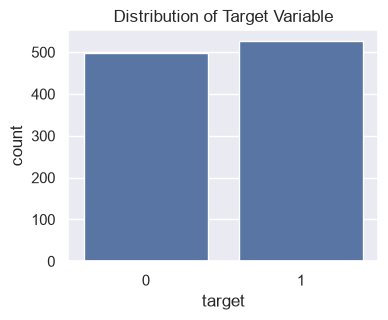

In [20]:
#visualize the target variable distribution
plt.figure(figsize=(4,3))
sns.countplot(x='target', data=df)
plt.title('Distribution of Target Variable')
plt.show()

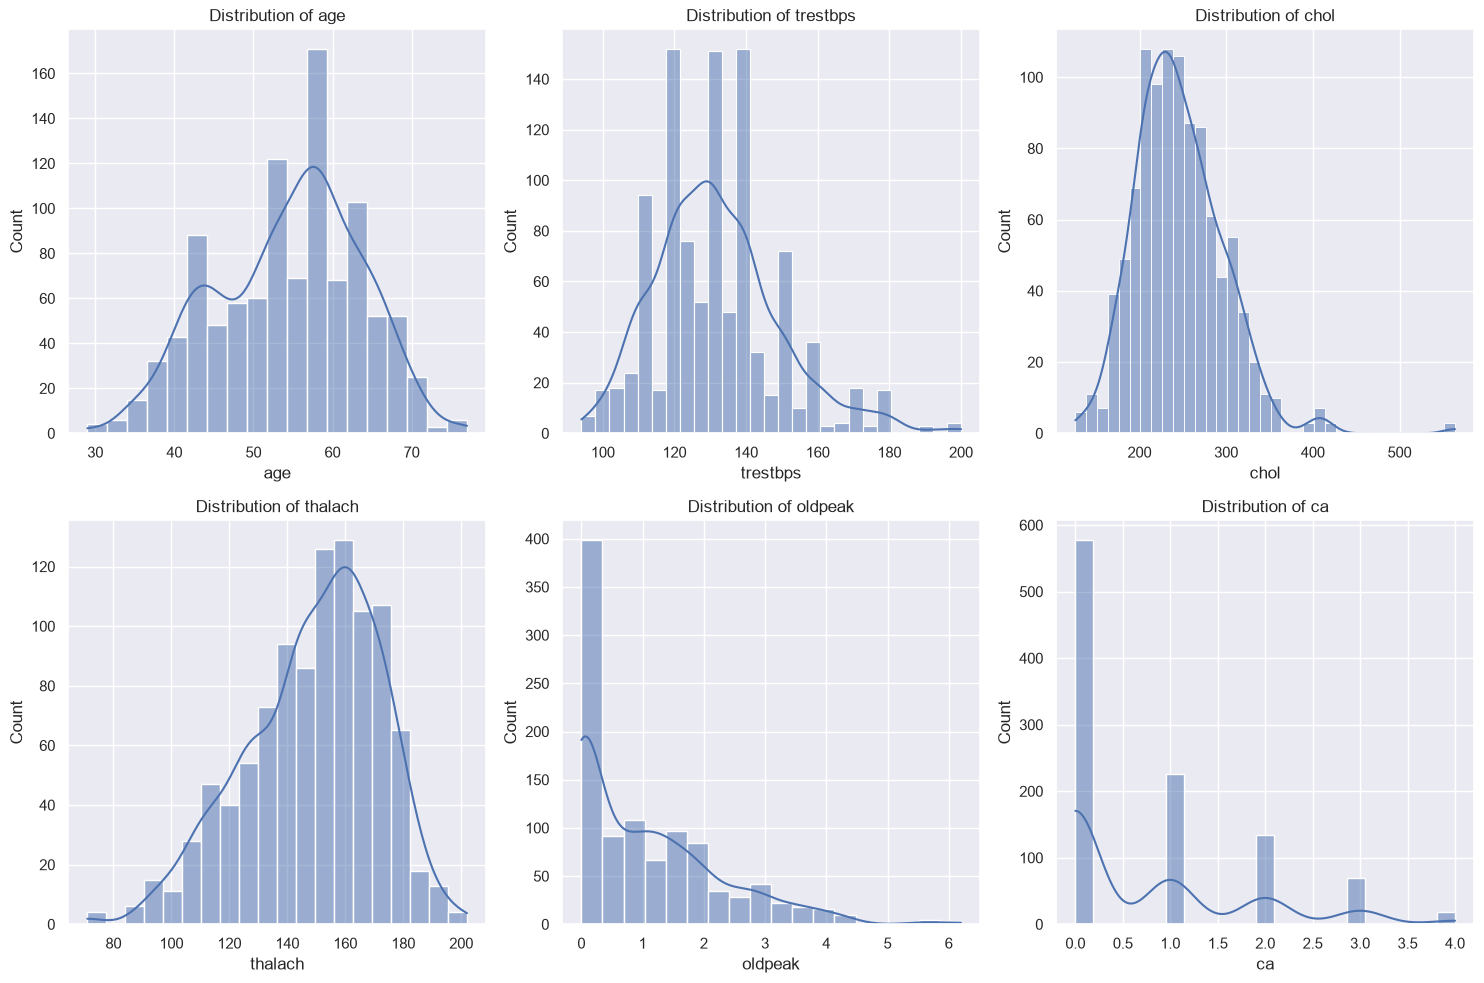

In [21]:
# histograms for numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i,col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

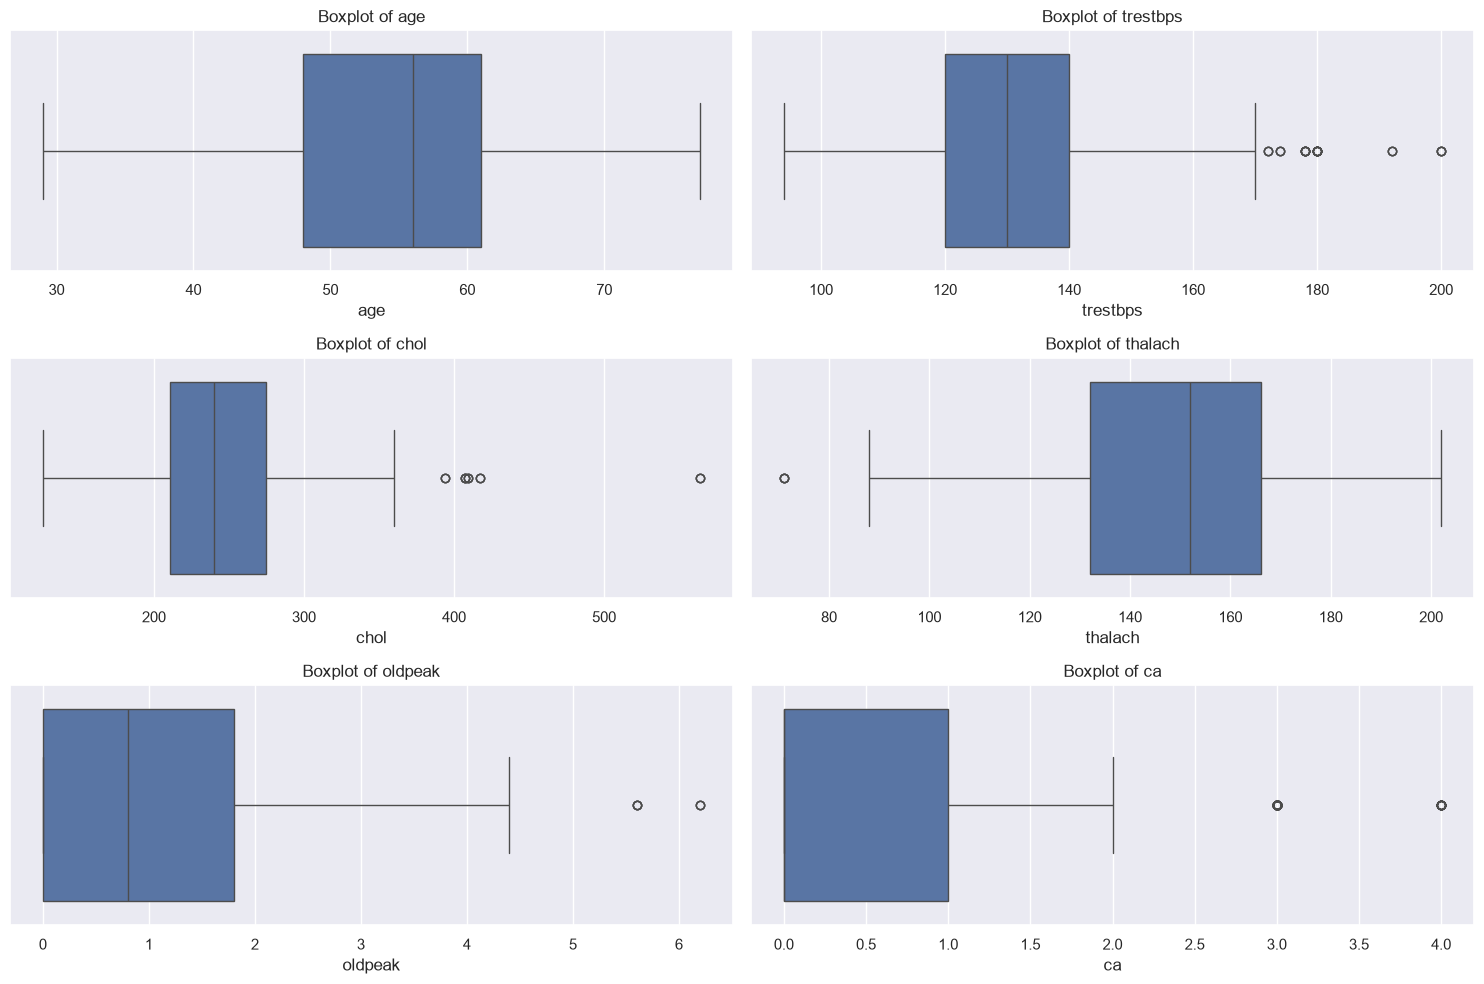

In [ ]:
#outlier detection using boxplots

fig, axes = plt.subplots(3, 2, figsize=(15, 10))
axes = axes.flatten()

for i,col in enumerate(numerical_features):
    sns.boxplot(x=df[col], ax=axes[i])
    axes[i].set_title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()